# Step 4: Oriented Bounding Box (OBB) Detection

Trains YOLO26-OBB and YOLO11-OBB at two scales each on the OBB Roboflow export, then compares OBB localisation to the HBB results from Step 2.

Runtime: A100 GPU, ~35-45 min for all four variants.

## Setup

In [1]:
!nvidia-smi

Mon Jun  1 17:09:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%pip install -q "ultralytics>=8.4.52" supervision pandas matplotlib pyyaml
!yolo settings sync=False
import ultralytics; ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 47.1/235.7 GB disk)


## Load OBB dataset from Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile, pathlib, yaml

ZIP_PATH = '/content/drive/MyDrive/IE/CV/roboflow/Pools.yolov8-obb.zip'
DATA_DIR = pathlib.Path('/content/dataset_obb')

DATA_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATA_DIR)

DATA_YAML = DATA_DIR / 'data.yaml'
cfg = yaml.safe_load(DATA_YAML.read_text())
cfg['path'] = str(DATA_DIR)
cfg['train'] = 'train/images'
cfg['val']   = 'valid/images'
cfg['test']  = 'test/images'
DATA_YAML.write_text(yaml.safe_dump(cfg))
print(yaml.safe_dump(cfg))

names:
  0: swimming pool
path: /content/dataset_obb
test: test/images
train: train/images
val: valid/images



## Training configuration

Hyperparameters identical to Step 2 so the HBB-vs-OBB comparison isn't confounded by training budget.

| Parameter | Value |
|---|---|
| Pretrained weights | yolo26n/s-obb, yolo11n/s-obb (DOTA) |
| Optimizer | AdamW |
| Initial LR | 0.005 |
| LR scheduler | Cosine |
| Epochs | 100 |
| Patience | 30 |
| Image size | 640 |
| Batch size | 16 |
| Mixed precision | AMP |
| Augmentations | HSV (0.015 / 0.7 / 0.4), translate 0.1, scale 0.5, flip lr/ud, rotate 180, mosaic 1.0, mixup 0.05, close_mosaic last 10 epochs |
| Hardware | NVIDIA A100 40 GB |

In [5]:
CFG = dict(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    patience=30,
    optimizer='AdamW',
    lr0=0.005,
    cos_lr=True,
    close_mosaic=10,
    seed=0,
    deterministic=True,
    cache='ram',
    plots=True,
    amp=True,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    translate=0.1, scale=0.5,
    fliplr=0.5, flipud=0.5,
    degrees=180,
    mosaic=1.0, mixup=0.05,
    exist_ok=True,
)
VARIANTS = ['yolo26n-obb', 'yolo26s-obb', 'yolo11n-obb', 'yolo11s-obb']

## Train all four variants

In [6]:
from ultralytics import YOLO
import time, gc, torch, pathlib

results = {}

for v in VARIANTS:
    print(f'\n=== {v} ===')
    gc.collect(); torch.cuda.empty_cache()
    t0 = time.time()
    model = YOLO(f'{v}.pt')
    train = model.train(name=v, **CFG)
    val = model.val(data=str(DATA_YAML), split='val', verbose=False)
    results[v] = {
        'mAP50':    float(val.box.map50),
        'mAP50_95': float(val.box.map),
        'precision': float(val.box.mp),
        'recall':    float(val.box.mr),
        'params':    sum(p.numel() for p in model.model.parameters()),
        'train_time_s': time.time() - t0,
        'best_weights': str(train.save_dir / 'weights' / 'best.pt'),
    }
    del model


=== yolo26n-obb ===
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset_obb/data.yaml, degrees=180, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo26n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n-obb, nbs=64, nms=False, opset=None, optimize=False, opti

## Comparison table and plots

In [7]:
import pandas as pd

df = pd.DataFrame(results).T
df['params_M'] = df['params'] / 1e6
df = df[['mAP50', 'mAP50_95', 'precision', 'recall', 'params_M', 'train_time_s']].round(4)
df.columns = ['mAP@50', 'mAP@50-95', 'Precision', 'Recall', 'Params (M)', 'Train time (s)']
df.to_csv('/content/obb_comparison.csv')
df

,mAP@50,mAP@50-95,Precision,Recall,Params (M),Train time (s)
yolo26n-obb,0.925382,0.697866,0.90247,0.839506,2.446602,335.104544
yolo26s-obb,0.942108,0.699242,0.953409,0.851852,9.751554,357.383761
yolo11n-obb,0.972833,0.723886,0.962845,0.876543,2.653918,239.656557
yolo11s-obb,0.955456,0.736482,0.899207,0.938272,9.699174,261.591661


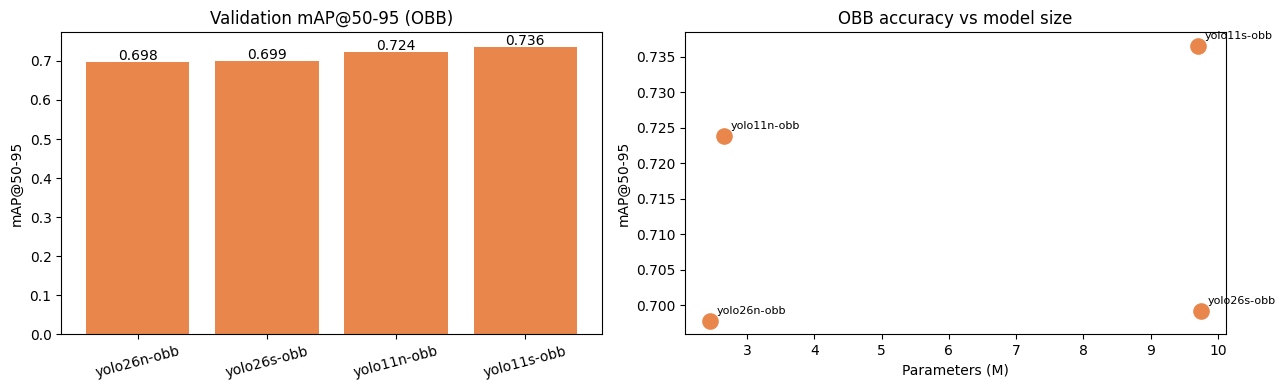

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(df.index, df['mAP@50-95'], color='#E8864C')
axes[0].set_ylabel('mAP@50-95'); axes[0].set_title('Validation mAP@50-95 (OBB)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(df['mAP@50-95']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center')

axes[1].scatter(df['Params (M)'], df['mAP@50-95'], s=120, c='#E8864C')
for name, row in df.iterrows():
    axes[1].annotate(name, (row['Params (M)'], row['mAP@50-95']), xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1].set_xlabel('Parameters (M)'); axes[1].set_ylabel('mAP@50-95'); axes[1].set_title('OBB accuracy vs model size')
plt.tight_layout(); plt.show()

## Best OBB variant diagnostic plots

Best OBB variant: yolo11s-obb
results.png


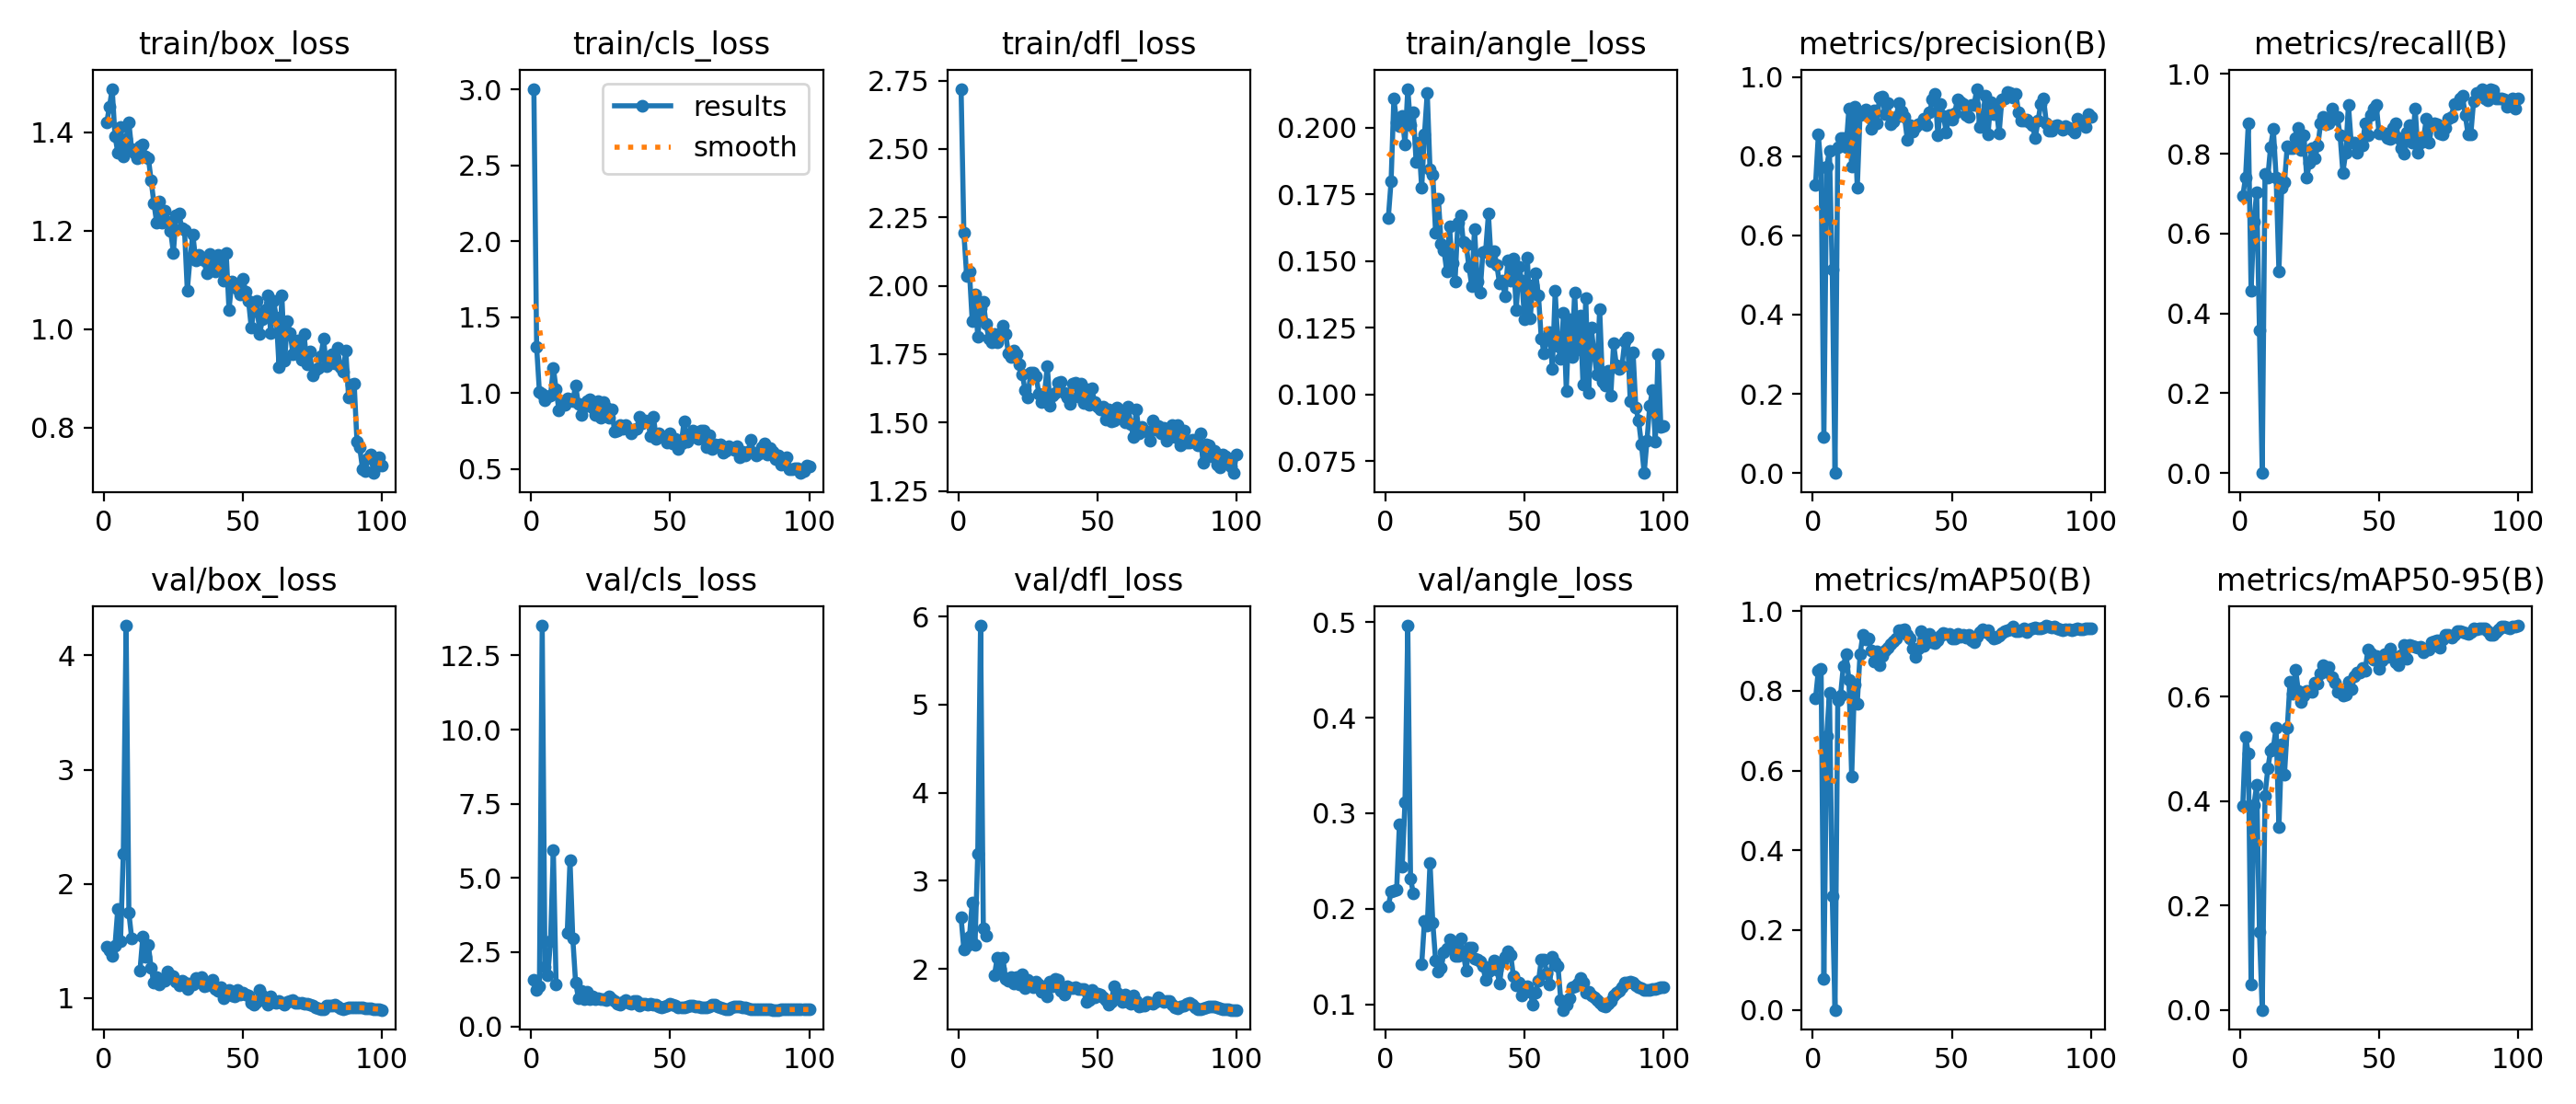

confusion_matrix.png


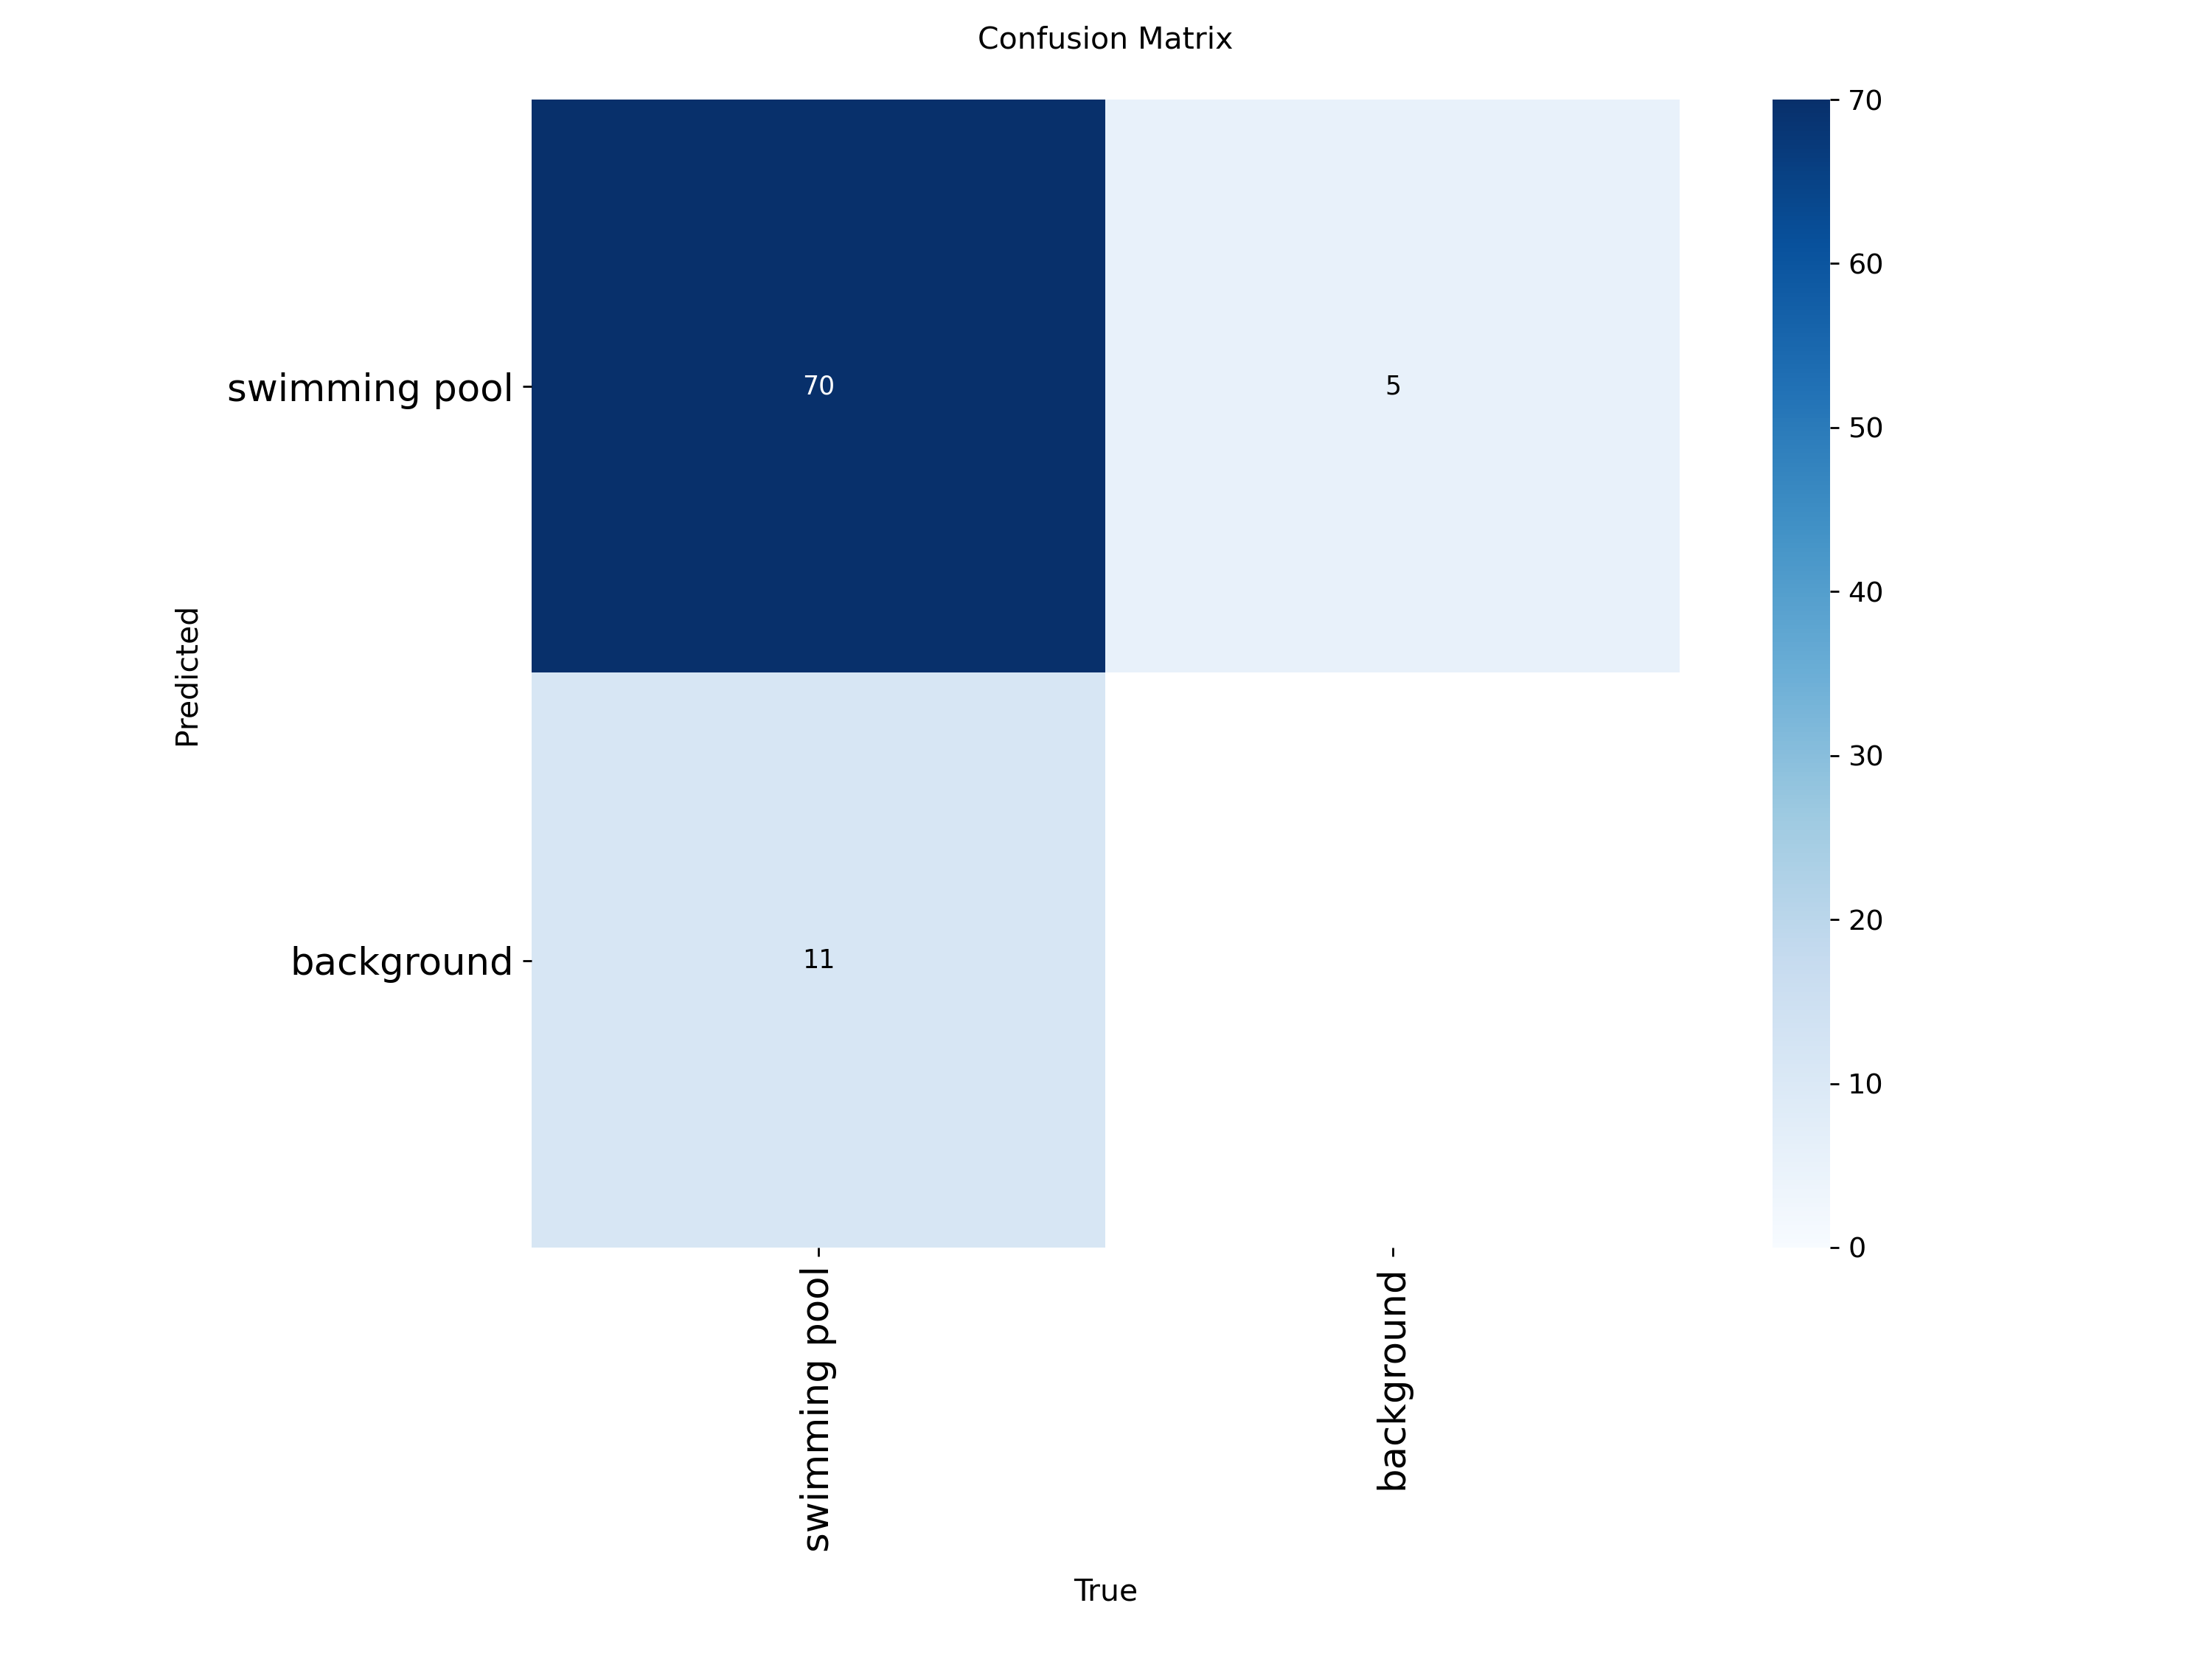

val_batch0_pred.jpg


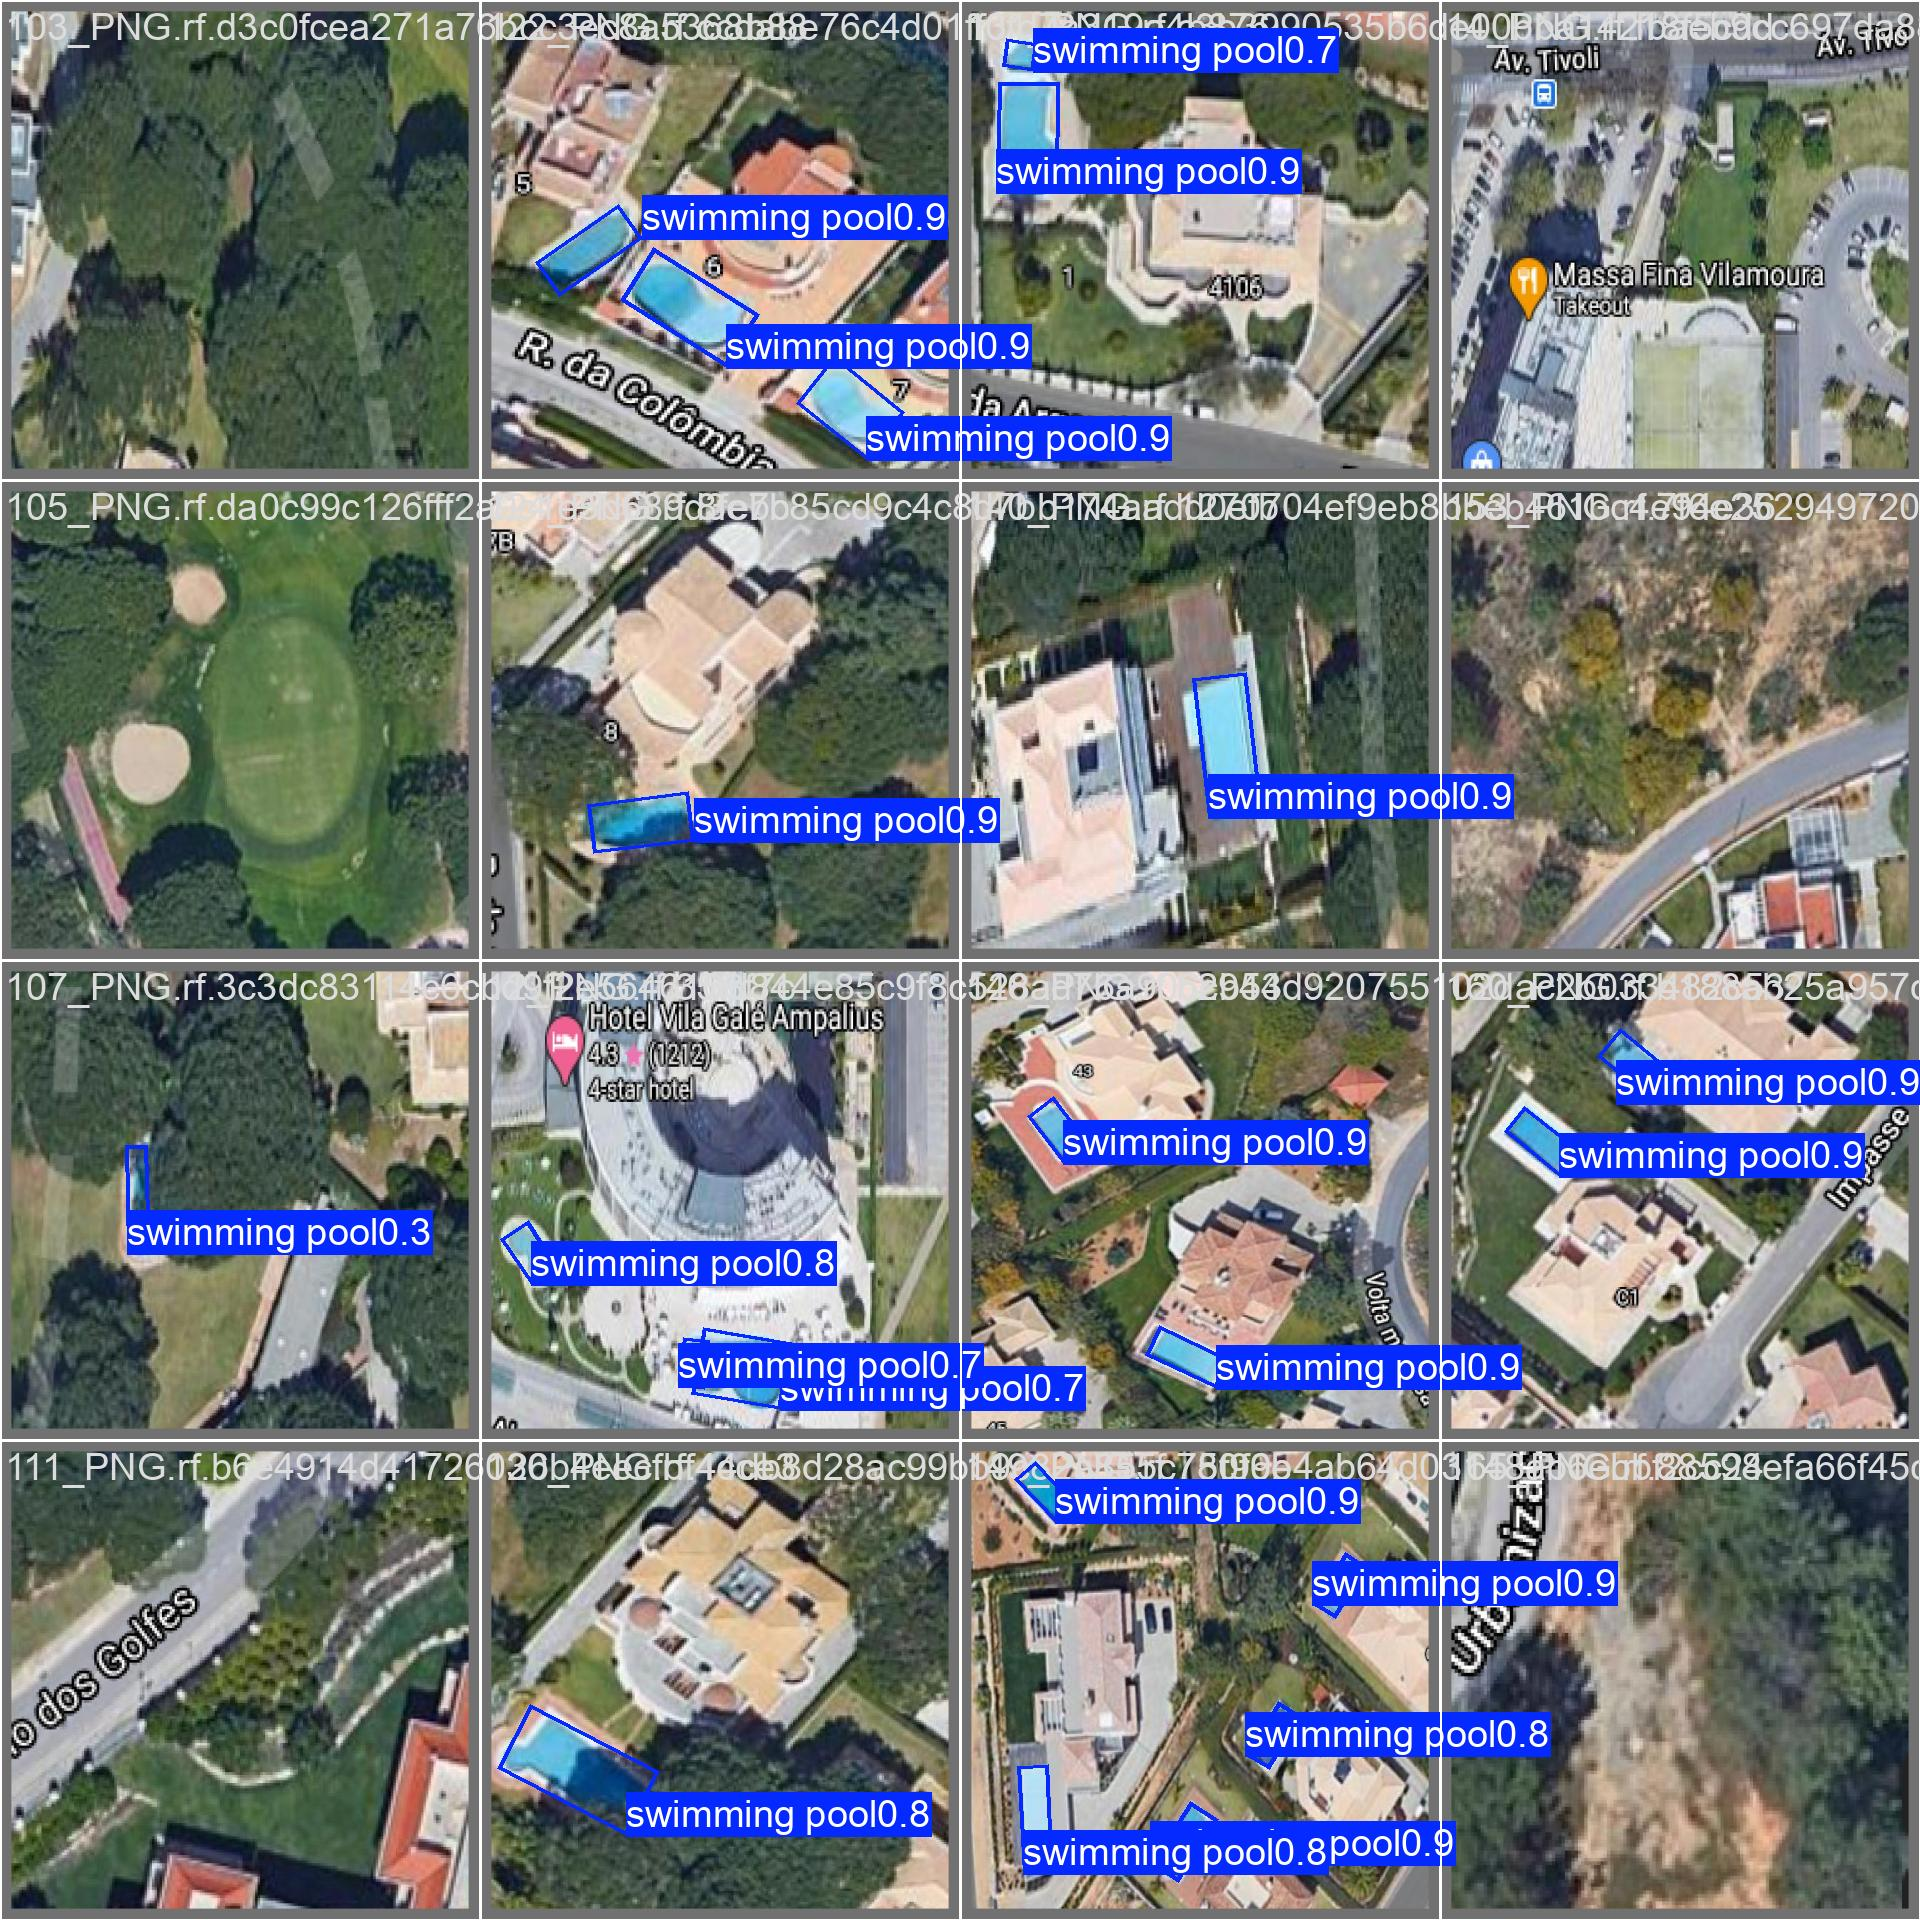

In [9]:
from IPython.display import Image as IPyImage, display

BEST = df['mAP@50-95'].idxmax()
print(f'Best OBB variant: {BEST}')
RUN_DIR = pathlib.Path(f'/content/runs/obb/{BEST}')
for f in ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'val_batch0_pred.jpg']:
    p = RUN_DIR / f
    if p.exists():
        print(f); display(IPyImage(filename=str(p), width=700))

## Test-set evaluation

In [10]:
best_model = YOLO(results[BEST]['best_weights'])
t = best_model.val(data=str(DATA_YAML), split='test', verbose=False)
print(f'TEST ({BEST}):  mAP50={t.box.map50:.4f}  mAP50-95={t.box.map:.4f}  P={t.box.mp:.4f}  R={t.box.mr:.4f}')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s-obb summary (fused): 110 layers, 9,699,174 parameters, 0 gradients, 22.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1852.3±408.1 MB/s, size: 65.4 KB)
val: Scanning /content/dataset_obb/test/labels... 29 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 1.6Kit/s 0.0s
val: New cache created: /content/dataset_obb/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.4it/s 0.8s
                   all         29         39      0.974      0.972      0.993      0.787
Speed: 3.3ms preprocess, 11.6ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/obb/val-5
TEST (yolo11s-obb):  mAP50=0.9933  mAP50-95=0.7868  P=0.9743  R=0.9720


## HBB vs OBB comparison

Pulls the YOLO26 HBB numbers from Step 2 (saved to Drive) and stacks them next to the OBB results for the discussion in the report.

In [11]:
HBB_CSV = '/content/drive/MyDrive/IE/CV/results/yolo26_hbb/comparison.csv'
try:
    df_hbb = pd.read_csv(HBB_CSV, index_col=0)
    df_combined = pd.concat([df_hbb.assign(task='HBB'), df.assign(task='OBB')])
    print('HBB (Step 2) vs OBB (Step 4) on the validation set:')
    print(df_combined.to_string())
    df_combined.to_csv('/content/hbb_vs_obb_comparison.csv')
except FileNotFoundError:
    print(f'Step 2 CSV not found at {HBB_CSV} -- run nb 2 first for the side-by-side')

HBB (Step 2) vs OBB (Step 4) on the validation set:
               mAP@50 mAP@50-95 Precision    Recall Params (M) Train time (s) task
yolo26n      0.912043  0.637144  0.895155  0.843284   2.375031     291.197755  HBB
yolo26s      0.891031  0.617326  0.862136  0.849268   9.465567      308.07662  HBB
yolo26m      0.902785  0.587363  0.876495  0.788556  20.350223       369.8425  HBB
yolo26l       0.90909   0.58978  0.944114  0.839506  24.746511      454.08956  HBB
yolo26n-obb  0.925382  0.697866   0.90247  0.839506   2.446602     335.104544  OBB
yolo26s-obb  0.942108  0.699242  0.953409  0.851852   9.751554     357.383761  OBB
yolo11n-obb  0.972833  0.723886  0.962845  0.876543   2.653918     239.656557  OBB
yolo11s-obb  0.955456  0.736482  0.899207  0.938272   9.699174     261.591661  OBB


## Failure analysis (best OBB variant, test set)

Matches predictions to GT by IoU on the axis-aligned bounding rectangle of each OBB and surfaces the highest-confidence false positives and the largest missed pools. The plot draws the rotated quadrilateral (red) on each failure case.

In [12]:
import cv2, numpy as np

TEST_IMG_DIR = DATA_DIR / 'test' / 'images'
TEST_LBL_DIR = DATA_DIR / 'test' / 'labels'

def load_obb_labels(p, w, h):
    polys, hbb = [], []
    if not p.exists(): return polys, hbb
    for line in p.read_text().splitlines():
        toks = line.split()
        if len(toks) < 9: continue
        xs = np.array([float(toks[i]) for i in (1, 3, 5, 7)]) * w
        ys = np.array([float(toks[i]) for i in (2, 4, 6, 8)]) * h
        polys.append(np.stack([xs, ys], axis=1))
        hbb.append([xs.min(), ys.min(), xs.max(), ys.max()])
    return polys, hbb

def iou(a, b):
    xA = max(a[0], b[0]); yA = max(a[1], b[1])
    xB = min(a[2], b[2]); yB = min(a[3], b[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / union if union > 0 else 0

IOU_TH = 0.5
fps, fns = [], []

for img_p in sorted(TEST_IMG_DIR.iterdir()):
    img = cv2.imread(str(img_p)); h, w = img.shape[:2]
    gt_polys, gt_hbb = load_obb_labels(TEST_LBL_DIR / (img_p.stem + '.txt'), w, h)

    r = best_model.predict(str(img_p), conf=0.25, verbose=False)[0]
    if r.obb is None or len(r.obb) == 0:
        for poly, hbb in zip(gt_polys, gt_hbb):
            area = (hbb[2]-hbb[0])*(hbb[3]-hbb[1])
            fns.append((img_p, poly, area))
        continue
    pred_polys = r.obb.xyxyxyxy.cpu().numpy()       # (n, 4, 2)
    pred_hbb   = r.obb.xyxy.cpu().numpy()           # axis-aligned
    pred_conf  = r.obb.conf.cpu().numpy()

    matched_gt, matched_pr = set(), set()
    for i in np.argsort(-pred_conf):
        for j, gh in enumerate(gt_hbb):
            if j in matched_gt: continue
            if iou(pred_hbb[i], gh) >= IOU_TH:
                matched_gt.add(j); matched_pr.add(int(i)); break

    for i in range(len(pred_polys)):
        if i not in matched_pr:
            fps.append((img_p, pred_polys[i], float(pred_conf[i])))
    for j in range(len(gt_polys)):
        if j not in matched_gt:
            area = (gt_hbb[j][2]-gt_hbb[j][0])*(gt_hbb[j][3]-gt_hbb[j][1])
            fns.append((img_p, gt_polys[j], area))

fps.sort(key=lambda x: -x[2])
fns.sort(key=lambda x: -x[2])
print(f'False positives: {len(fps)}   False negatives: {len(fns)}')

False positives: 0   False negatives: 3


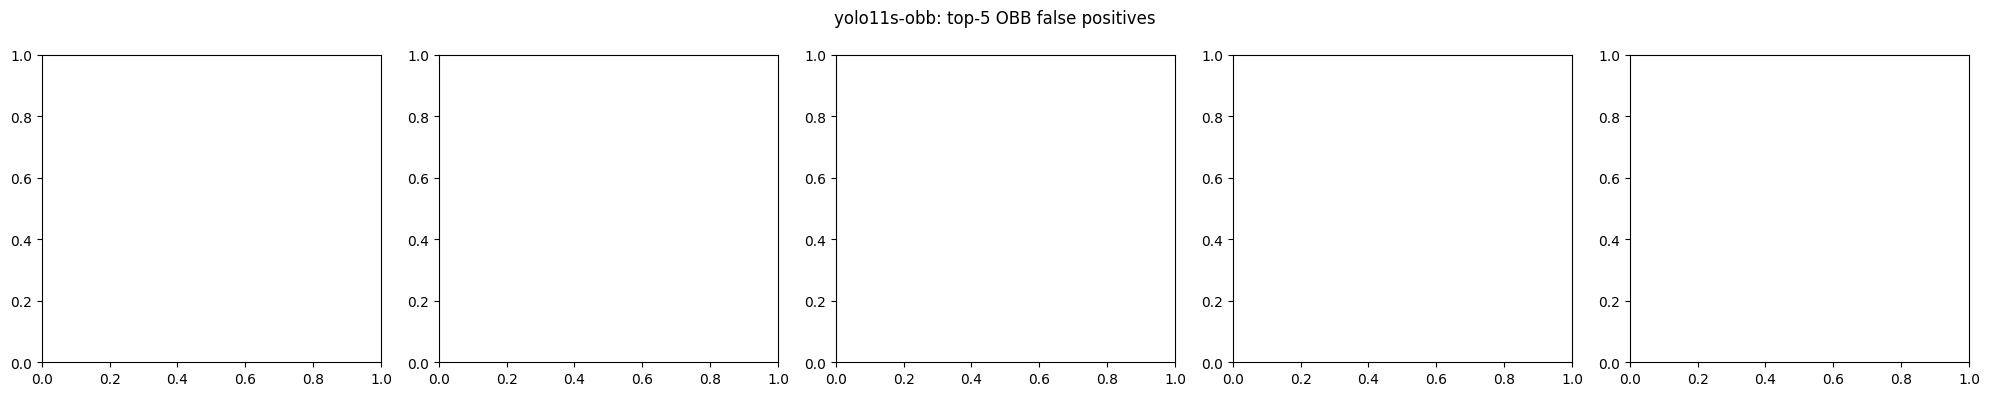

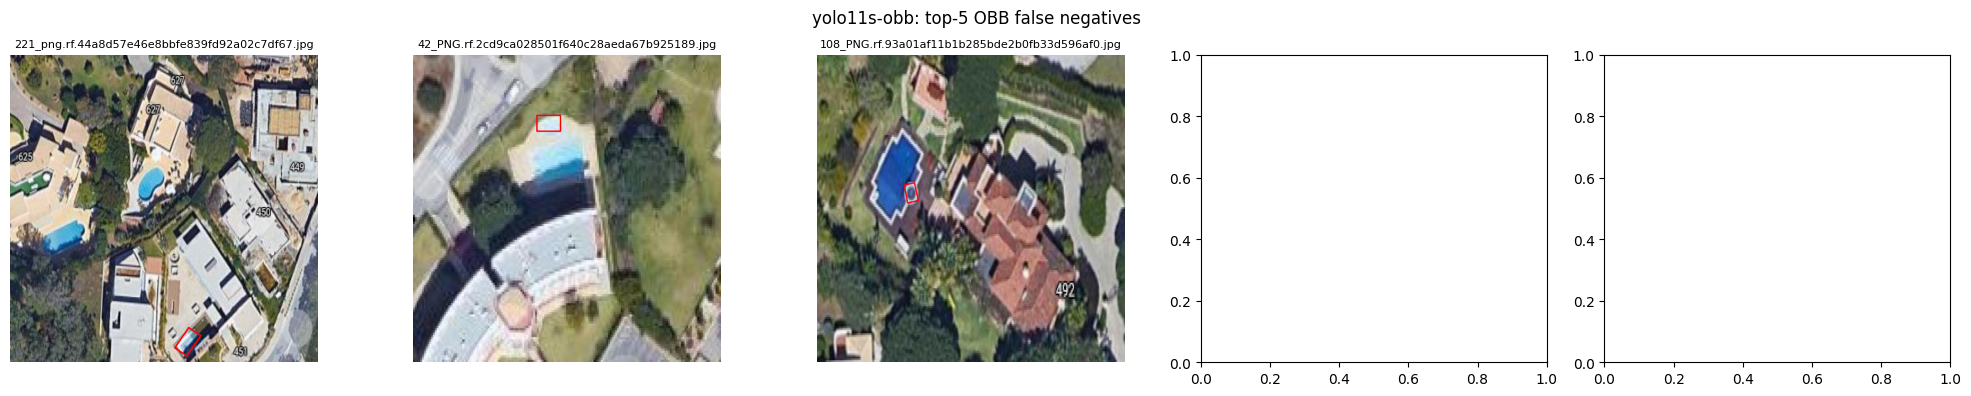

In [13]:
def show_obb(items, title, n=5):
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    for ax, (img_p, poly, _) in zip(axes, items[:n]):
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        pts = poly.astype(int).reshape(-1, 1, 2)
        cv2.polylines(img, [pts], isClosed=True, color=(255, 0, 0), thickness=2)
        ax.imshow(img); ax.set_title(img_p.name, fontsize=8); ax.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_obb(fps, f'{BEST}: top-5 OBB false positives')
show_obb(fns, f'{BEST}: top-5 OBB false negatives')

## Save results to Drive

In [14]:
import shutil

OUT = pathlib.Path('/content/drive/MyDrive/IE/CV/results/obb')
OUT.mkdir(parents=True, exist_ok=True)

df.to_csv(OUT / 'comparison.csv')
for v in VARIANTS:
    src = pathlib.Path(results[v]['best_weights'])
    if src.exists():
        shutil.copy(src, OUT / f'{v}_best.pt')
print(f'Saved to {OUT}')

Saved to /content/drive/MyDrive/IE/CV/results/obb
